#Genome Selection and Representative Sampling


##1. Llamado de archivos

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. IMPORTACIONES
# ─────────────────────────────────────────────────────────────────────────────
import os
import time
import zipfile
import requests
import pandas as pd
import gdown
import shutil
import tarfile
import glob

# ─────────────────────────────────────────────────────────────────────────────
# 3. CONFIGURACIÓN DE CONSTANTES Y RUTAS
# ─────────────────────────────────────────────────────────────────────────────
# IDs de Google Drive
ID_EXCEL    = '16tt8sjX2oN3H6I0_7VLtyvsT6Jj4oJjC'
ID_ZIP_REFS = '1bBG-cwhb3u-ydIo_A1LoO04yxkOrLhNI'

# Rutas: Separación estricta de Proteomas (.faa) y Genomas/CDS (.ffn)
RUTA_REFS_PROT = "/content/Proteomas_referencia"
RUTA_REFS_GEN  = "/content/Genomas_referencia"
RUTA_ESTUDIO_PROT = "/content/Proteomas_estudio"
RUTA_ESTUDIO_GEN  = "/content/Genomas_estudio"

RUTA_EXCEL = "/content/Supplementary_Data_2_255_refs.xlsx"

# Lista original de accesiones de interés (Perú)
ACCESIONES_PERU = [
    "GCA_016749025.1", "GCA_016748925.1", "GCA_016748795.1", "GCA_016748675.1",
    "GCA_016748555.1", "GCA_016749715.1", "GCA_016749815.1", "GCA_016749575.1",
    "GCA_016749455.1", "GCA_016749215.1", "GCA_016749335.1", "GCA_016749085.1",
    "GCA_016755815.1", "GCA_016755795.1", "GCA_016755775.1", "GCA_016755755.1",
    "GCA_016755735.1", "GCA_016755715.1", "GCA_016755695.1", "GCA_016755675.1",
    "GCA_016755655.1", "GCA_016755635.1", "GCA_016755615.1", "GCA_016757595.1",
    "GCA_016757535.1", "GCA_016757575.1", "GCA_016757555.1"
]

# ─────────────────────────────────────────────────────────────────────────────
# 4. DEFINICIÓN DE FUNCIONES
# ─────────────────────────────────────────────────────────────────────────────

def descargar_metadatos_referencia():
    """Descarga el archivo Excel con la data suplementaria desde Drive."""
    print("Descargando metadatos (Excel) desde Drive...")
    url_excel = f'https://drive.google.com/uc?id={ID_EXCEL}'
    gdown.download(url_excel, RUTA_EXCEL, quiet=True)

def validar_metadatos_referencia():
    """Carga y limpia el archivo Excel, verificando las columnas clave."""
    if not os.path.exists(RUTA_EXCEL):
        print(f"Error: No se encontró el archivo Excel en {RUTA_EXCEL}")
        return None

    df_refs = pd.read_excel(RUTA_EXCEL, skiprows=0)
    df_refs.columns = df_refs.columns.astype(str).str.strip().str.replace('\n', ' ')

    col_pop = 'Previously assigned Hp population'
    if col_pop not in df_refs.columns:
        print(f"\n[!] Error: No encontré la columna '{col_pop}'")
        return None
    else:
        print(f"Éxito: Se cargaron los metadatos de {len(df_refs)} genomas.")
        return df_refs

def descargar_y_clasificar_referencias():
    """Descarga el .tar.gz mundial, extrae y separa CDS (.ffn) de proteomas (.faa)."""
    os.makedirs(RUTA_REFS_PROT, exist_ok=True)
    os.makedirs(RUTA_REFS_GEN, exist_ok=True)
    ruta_tmp = "/content/temp_refs"
    os.makedirs(ruta_tmp, exist_ok=True)

    url_archivo = f'https://drive.google.com/uc?id={ID_ZIP_REFS}'
    output_archivo = "/content/referencias.tar.gz"

    print("\nDescargando secuencias de referencia mundiales desde Drive...")
    gdown.download(url_archivo, output_archivo, quiet=True)

    print("Extrayendo archivos (tar.gz)...")
    try:
        with tarfile.open(output_archivo, "r:gz") as tar_ref:
            tar_ref.extractall(path=ruta_tmp, filter='data')
    except tarfile.ReadError:
        print("Error: El archivo no es un .tar.gz válido. Revisa el ID de Drive.")
        return

    print("Clasificando archivos...")
    for root, dirs, files in os.walk(ruta_tmp):
        for file in files:
            ruta_origen = os.path.join(root, file)
            # Proteomas
            if file.endswith('.faa'):
                shutil.move(ruta_origen, os.path.join(RUTA_REFS_PROT, file))
            # Secuencias nucleotídicas / CDS
            elif file.endswith(('.ffn')):
                shutil.move(ruta_origen, os.path.join(RUTA_REFS_GEN, file))

    # Limpieza de la carpeta temporal extraída
    shutil.rmtree(ruta_tmp)

    n_prot = len(os.listdir(RUTA_REFS_PROT))
    n_gen  = len(os.listdir(RUTA_REFS_GEN))
    print(f"Listo: {n_prot} proteomas y {n_gen} genomas/CDS de referencia organizados.")

def descargar_y_clasificar_estudio():
    """Descarga proteomas (.faa) y CDS (.ffn) de las cepas peruanas.
    Si falla GenBank (GCA), intenta automáticamente con RefSeq (GCF)."""
    os.makedirs(RUTA_ESTUDIO_PROT, exist_ok=True)
    os.makedirs(RUTA_ESTUDIO_GEN, exist_ok=True)

    base_api = "https://api.ncbi.nlm.nih.gov/datasets/v2/genome/accession"
    cepas_unicas = set(ACCESIONES_PERU)

    print(f"\nIniciando descarga de {len(cepas_unicas)} cepas peruanas desde NCBI...")

    params = [
        ("include_annotation_type", "PROT_FASTA"),
        ("include_annotation_type", "CDS_FASTA")
    ]

    for acc_original in cepas_unicas:
        out_prot = os.path.join(RUTA_ESTUDIO_PROT, f"Peru_{acc_original}.faa")
        out_gen  = os.path.join(RUTA_ESTUDIO_GEN, f"Peru_{acc_original}.ffn")

        if os.path.exists(out_prot) and os.path.exists(out_gen):
            print(f" -> Ya existen archivos para la cepa: {acc_original} (Omitiendo)")
            continue

        descargado = False
        # Lista de accesiones a intentar: la original y, si es GCA, su pareja GCF
        intentos = [acc_original]
        if acc_original.startswith("GCA_"):
            intentos.append(acc_original.replace("GCA_", "GCF_"))

        for acc_actual in intentos:
            zip_file = f"/content/{acc_actual}.tmp.zip"
            try:
                if acc_actual != acc_original:
                    print(f"    ... Reintentando con RefSeq: {acc_actual}")

                r = requests.get(
                    f"{base_api}/{acc_actual}/download",
                    params=params,
                    timeout=60
                )
                r.raise_for_status()

                with open(zip_file, "wb") as f:
                    f.write(r.content)

                with zipfile.ZipFile(zip_file) as z:
                    faa_files = [x for x in z.namelist() if x.endswith(".faa")]
                    ffn_files = [x for x in z.namelist() if "cds" in x.lower() or x.endswith((".ffn", ".fna")) and not x.endswith(".faa")]

                    if faa_files and ffn_files:
                        with z.open(faa_files[0]) as src, open(out_prot, "w") as dst:
                            for line in src: dst.write(line.decode())

                        with z.open(ffn_files[0]) as src, open(out_gen, "w") as dst:
                            for line in src: dst.write(line.decode())

                        descargado = True

                if descargado: break # Salir del bucle de intentos si tuvo éxito

            except Exception:
                continue # Probar el siguiente intento si existe

            finally:
                if os.path.exists(zip_file):
                    os.remove(zip_file)

        if descargado:
            print(f" -> ÉXITO: Guardado como Peru_{acc_original}")
        else:
            print(f" -> ❌ FALLO CRÍTICO: No se pudo descargar {acc_original} ni su versión RefSeq.")

        time.sleep(0.3)

    n_prot = len(os.listdir(RUTA_ESTUDIO_PROT))
    n_gen  = len(os.listdir(RUTA_ESTUDIO_GEN))
    print(f"\nRESUMEN: {n_prot} proteomas y {n_gen} CDS peruanos listos.")

def limpieza_absoluta():
    """Realiza un barrido final para asegurar que no quede ningún archivo comprimido suelto en /content."""
    print("\nRealizando limpieza de archivos comprimidos...")
    archivos_basura = glob.glob("/content/*.tmp.zip") + glob.glob("/content/*.tar.gz")

    for archivo in archivos_basura:
        try:
            os.remove(archivo)
        except OSError:
            pass
    print("Limpieza completada. Solo quedaron las 4 carpetas de trabajo y el Excel.")

# ─────────────────────────────────────────────────────────────────────────────
# 5. BLOQUE DE EJECUCIÓN PRINCIPAL
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("=== INICIANDO PIPELINE DE DESCARGA Y CLASIFICACIÓN ===")

    descargar_metadatos_referencia()
    df_referencias = validar_metadatos_referencia()

    descargar_y_clasificar_referencias()

    descargar_y_clasificar_estudio()

    # Ejecutamos el barrido final de zips
    limpieza_absoluta()

    print("\n=== PIPELINE FINALIZADO CON ÉXITO ===")

=== INICIANDO PIPELINE DE DESCARGA Y CLASIFICACIÓN ===
Descargando metadatos (Excel) desde Drive...
Éxito: Se cargaron los metadatos de 255 genomas.

Descargando secuencias de referencia mundiales desde Drive...
Extrayendo archivos (tar.gz)...
Clasificando archivos...
Listo: 255 proteomas y 255 genomas/CDS de referencia organizados.

Iniciando descarga de 27 cepas peruanas desde NCBI...
 -> ÉXITO: Guardado como Peru_GCA_016749715.1
 -> ÉXITO: Guardado como Peru_GCA_016749335.1
 -> ÉXITO: Guardado como Peru_GCA_016748675.1
 -> ÉXITO: Guardado como Peru_GCA_016755715.1
 -> ÉXITO: Guardado como Peru_GCA_016749455.1
 -> ÉXITO: Guardado como Peru_GCA_016757555.1
 -> ÉXITO: Guardado como Peru_GCA_016749025.1
 -> ÉXITO: Guardado como Peru_GCA_016755755.1
 -> ÉXITO: Guardado como Peru_GCA_016755735.1
 -> ÉXITO: Guardado como Peru_GCA_016755615.1
    ... Reintentando con RefSeq: GCF_016748925.1
 -> ÉXITO: Guardado como Peru_GCA_016748925.1
 -> ÉXITO: Guardado como Peru_GCA_016755675.1
 -> ÉXITO

##2. Filtro (eliminar referencias de Perú) y realizar el muestreo balanceado (n=3)


In [2]:
import os
import shutil
import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# 4. FILTRADO ESTRATÉGICO Y PREPARACIÓN DE CARPETA DE ANÁLISIS
# ─────────────────────────────────────────────────────────────────────────────

# 1. Recuperar variables y el DataFrame correcto del bloque anterior
col_pop = 'Previously assigned Hp population'
col_acc = 'Accession and Hyperlink'

# Asignamos df_refs usando el DataFrame que generó la función anterior
df_refs = df_referencias.copy()

# Parámetros del Filtro
N_FINAL = 3  # Genomas por población
TAMANO_MIN = 1500000 # 1.5 MB
TAMANO_MAX = 1900000 # 1.9 MB
RUTA_ANALISIS = '/content/Proteomas_totales'

# 2. Aplicar el Embudo (Filtro de Tamaño y Geografía)
# Usamos fillna('') para evitar que los valores nulos rompan la función .str
df_embudo = df_refs[
    (~df_refs['Country'].fillna('').str.strip().str.contains('Peru', case=False)) &
    (pd.to_numeric(df_refs['Bases'], errors='coerce') >= TAMANO_MIN) &
    (pd.to_numeric(df_refs['Bases'], errors='coerce') <= TAMANO_MAX)
].copy()

print(f"Genomas que pasaron el filtro de tamaño y geografía: {len(df_embudo)}")

# 3. Selección por Calidad (Contigs) y Diversidad de Países
indices_seleccionados = []
poblaciones = df_embudo[col_pop].unique()

for pop in poblaciones:
    if pd.isna(pop): continue

    # Asegurar que Contigs sea numérico antes de ordenar
    df_embudo['Contigs'] = pd.to_numeric(df_embudo['Contigs'], errors='coerce')
    grupo = df_embudo[df_embudo[col_pop] == pop].sort_values(by='Contigs', ascending=True)

    seleccion_linaje = []
    paises_usados = set()

    for idx, fila in grupo.iterrows():
        if len(seleccion_linaje) < N_FINAL:
            pais = fila['Country']
            if pd.notna(pais) and pais not in paises_usados:
                seleccion_linaje.append(idx)
                paises_usados.add(pais)

    # Si no hay 3 países distintos, rellenar con los siguientes mejores en calidad
    if len(seleccion_linaje) < N_FINAL:
        for idx in grupo.index:
            if idx not in seleccion_linaje and len(seleccion_linaje) < N_FINAL:
                seleccion_linaje.append(idx)

    indices_seleccionados.extend(seleccion_linaje)

df_seleccion_final = df_refs.loc[indices_seleccionados]

# 4. Preparar carpeta física y copiar archivos
if os.path.exists(RUTA_ANALISIS):
    shutil.rmtree(RUTA_ANALISIS)
os.makedirs(RUTA_ANALISIS, exist_ok=True)

print(f"Copiando archivos a {RUTA_ANALISIS}...")

# A. Copiar Referencias Seleccionadas
archivos_en_refs = os.listdir(RUTA_REFS_PROT)
count_refs = 0

for _, fila in df_seleccion_final.iterrows():
    # Extracción robusta de la accesión
    acc_raw = str(fila[col_acc])
    acc = acc_raw.split('/')[-1].split(' ')[0].strip()
    cepa = str(fila['Strain name']).strip()

    encontrado = False
    for f in archivos_en_refs:
        # Se verifica que termine en .faa para evitar arrastrar otros formatos
        if (acc in f or cepa in f) and f.endswith('.faa'):
            shutil.copy(os.path.join(RUTA_REFS_PROT, f), os.path.join(RUTA_ANALISIS, f))
            count_refs += 1
            encontrado = True
            break

    if not encontrado:
        print(f"  [Aviso] No se encontró proteoma para: {cepa} ({acc})")

# B. Copiar Cepas de Perú (Grupo de estudio)
count_peru = 0
if os.path.exists(RUTA_ESTUDIO_PROT):
    for f in os.listdir(RUTA_ESTUDIO_PROT):
        if f.endswith('.faa'):
            shutil.copy(os.path.join(RUTA_ESTUDIO_PROT, f), os.path.join(RUTA_ANALISIS, f))
            count_peru += 1

# ─────────────────────────────────────────────────────────────────────────────
# 5. REPORTE FINAL
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*40)
print(f"REFERENCIAS COPIADAS: {count_refs}")
print(f"CEPAS PERÚ COPIADAS: {count_peru}")
print(f"TOTAL EN '{RUTA_ANALISIS}': {count_refs + count_peru}")
print("="*40)

print("\nPaíses representados en las referencias (máx 3 cepas por población):")
print(df_seleccion_final['Country'].value_counts())

print("DESGLOSE POR LINAJE (SUBPOBLACIÓN):")
# Esto cuenta cuántos genomas seleccionó de cada población/subpoblación
print(df_seleccion_final[col_pop].value_counts())

print("\nMUESTRA DEL CONTENIDO FINAL:")
# Muestra los primeros 10 para ver la relación Población - País
with pd.option_context('display.max_rows', None):
    display(df_seleccion_final[[col_pop, 'Country', 'Strain name']])

Genomas que pasaron el filtro de tamaño y geografía: 243
Copiando archivos a /content/Proteomas_totales...

REFERENCIAS COPIADAS: 51
CEPAS PERÚ COPIADAS: 27
TOTAL EN '/content/Proteomas_totales': 78

Países representados en las referencias (máx 3 cepas por población):
Country
Russia              8
South Africa        5
United States       4
Australia           3
Gambia              2
Venezuela           2
Mexico              2
Colombia            2
Canada              2
England             1
Sudan               1
Ethiopia            1
Nicaragua           1
Angola              1
Italy               1
Germany             1
United Kingdom      1
Sweden              1
Honduras            1
Belgium             1
Portugal            1
Spain               1
Mongolia            1
India               1
Myanmar             1
Nepal               1
Papua New Guinea    1
South Korea         1
Japan               1
China               1
Name: count, dtype: int64
DESGLOSE POR LINAJE (SUBPOBLACIÓN):
P

,Previously assigned Hp population,Country,Strain name
1,hpAfrica2,Angola,K26A1
14,hpAfrica2,South Africa,SouthAfrica20
13,hpAfrica2,South Africa,SouthAfrica50
24,hpNEAfrica,Australia,HP14039
23,hpNEAfrica,Ethiopia,HP13068
17,hpNEAfrica,Sudan,HP08058
32,hspAfrica1LatinAmerica,United States,HpP_8
44,hspAfrica1LatinAmerica,Venezuela,VE-HV055
37,hspAfrica1LatinAmerica,Nicaragua,Nic30_A
57,hspAfrica1SAfrica,South Africa,SA35C


In [3]:
print("DESGLOSE POR LINAJE (SUBPOBLACIÓN):")
# Esto cuenta cuántos genomas seleccionó de cada población/subpoblación
print(df_seleccion_final[col_pop].value_counts())

print("\nMUESTRA DEL CONTENIDO FINAL:")
# Muestra los primeros 10 para ver la relación Población - País
display(df_seleccion_final[[col_pop, 'Country', 'Strain name']].head(10))

DESGLOSE POR LINAJE (SUBPOBLACIÓN):
Previously assigned Hp population
hpAfrica2                  3
hpNEAfrica                 3
hspAfrica1LatinAmerica     3
hspAfrica1SAfrica          3
hspAfrica1WAfrica          3
hspNEurope                 3
hspSEurope                 3
hspSWEurope                3
hspSWEuropeLatinAmerica    3
hpNorthAsia                3
hspIndigenousNAmerica      3
hspIndigenousSAmerica      3
hspSiberia                 3
hspUral                    3
hpAsia2                    3
hpSahul                    3
hspEAsia                   3
Name: count, dtype: int64

MUESTRA DEL CONTENIDO FINAL:


,Previously assigned Hp population,Country,Strain name
1,hpAfrica2,Angola,K26A1
14,hpAfrica2,South Africa,SouthAfrica20
13,hpAfrica2,South Africa,SouthAfrica50
24,hpNEAfrica,Australia,HP14039
23,hpNEAfrica,Ethiopia,HP13068
17,hpNEAfrica,Sudan,HP08058
32,hspAfrica1LatinAmerica,United States,HpP_8
44,hspAfrica1LatinAmerica,Venezuela,VE-HV055
37,hspAfrica1LatinAmerica,Nicaragua,Nic30_A
57,hspAfrica1SAfrica,South Africa,SA35C


In [4]:
# -og: Solo ortogrupos (sin árboles pesados)
# -S diamond: Búsqueda ultra rápida de proteínas
# -t 8: Usa todos los núcleos de CPU disponibles
!./OrthoFinder/orthofinder -f /content/Proteomas_totales -t 8 -og -S diamond

/bin/bash: line 1: ./OrthoFinder/orthofinder: No such file or directory


#4. Limpieza de OG

In [5]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 64.0 MB/s eta 0:00:00


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. IMPORTACIONES
# ─────────────────────────────────────────────────────────────────────────────
import os
import shutil
import zipfile
import gdown

# ─────────────────────────────────────────────────────────────────────────────
# 2. CONFIGURACIÓN
# ─────────────────────────────────────────────────────────────────────────────
# Reemplaza esto con el ID de tu archivo .zip de OrthoFinder en Google Drive
ID_ORTHOFINDER = '1JtD7a1vjyDoYKeLjiEE4F1-H3CnCS_hA'

ARCHIVO_COMPRIMIDO = "/content/Resultados_OrthoFinder.zip"
DIR_EXTRACCION     = "/content/Temp_OrthoFinder"
DIR_GENES_INTERES  = "/content/Genes_Virulencia"

# Diccionario con los ortogrupos que buscas y sus respectivos nombres de genes
ORTOGRUPOS_OBJETIVO = {
    "OG0001326": "CagA",
    "OG0000047": "BabA",
    "OG0000123": "VacA",
    "OG0000053" :"UreB",
    "OG0000366": "NapA",
    "OG0000677": "HpaA",
    "OG0000029": "OipA",
    "OG0001247": "HomA"
}

# ─────────────────────────────────────────────────────────────────────────────
# 3. FUNCIONES
# ─────────────────────────────────────────────────────────────────────────────

def descargar_y_descomprimir():
    """Descarga el ZIP desde Drive y lo extrae en una carpeta temporal."""
    if not os.path.exists(DIR_EXTRACCION):
        os.makedirs(DIR_EXTRACCION)

    print("Descargando resultados de OrthoFinder desde Drive...")
    url = f'https://drive.google.com/uc?id={ID_ORTHOFINDER}'
    gdown.download(url, ARCHIVO_COMPRIMIDO, quiet=False)

    print("\nDescomprimiendo archivo...")
    with zipfile.ZipFile(ARCHIVO_COMPRIMIDO, 'r') as zip_ref:
        zip_ref.extractall(DIR_EXTRACCION)
    print("Descompresión finalizada.")

def extraer_genes_interes():
    if not os.path.exists(DIR_GENES_INTERES):
        os.makedirs(DIR_GENES_INTERES)

    print("\nBuscando ortogrupos de interés...")
    archivos_encontrados = 0

    for root, dirs, files in os.walk(DIR_EXTRACCION):
        # ── Solo entrar a Orthogroup_Sequences, ignorar todo lo demás ──
        if "Orthogroup_Sequences" not in root:
            continue

        for file in files:
            for og_id, gene_name in ORTOGRUPOS_OBJETIVO.items():
                if file.startswith(og_id) and file.endswith(('.fa', '.fasta', '.faa', '.ffn')):
                    ruta_origen  = os.path.join(root, file)
                    ext          = os.path.splitext(file)[1]
                    nuevo_nombre = f"{og_id}_{gene_name}{ext}"
                    ruta_destino = os.path.join(DIR_GENES_INTERES, nuevo_nombre)

                    shutil.copy2(ruta_origen, ruta_destino)
                    print(f" -> Extraído: {nuevo_nombre}")
                    archivos_encontrados += 1

    print(f"\nSe aislaron {archivos_encontrados} archivos crudos (sin alinear).")

def limpieza_temporal():
    """Elimina el ZIP descargado y la carpeta de extracción masiva para ahorrar espacio."""
    print("\nRealizando limpieza de archivos pesados y temporales...")

    if os.path.exists(ARCHIVO_COMPRIMIDO):
        os.remove(ARCHIVO_COMPRIMIDO)

    if os.path.exists(DIR_EXTRACCION):
        shutil.rmtree(DIR_EXTRACCION)

    print("Limpieza completada.")

# ─────────────────────────────────────────────────────────────────────────────
# 4. EJECUCIÓN
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("=== INICIANDO EXTRACCIÓN DE ORTOGRUPOS ===")

    descargar_y_descomprimir()
    extraer_genes_interes()
    limpieza_temporal()

    print("\n=== PROCESO FINALIZADO CON ÉXITO ===")

=== INICIANDO EXTRACCIÓN DE ORTOGRUPOS ===
Descargando resultados de OrthoFinder desde Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1JtD7a1vjyDoYKeLjiEE4F1-H3CnCS_hA
From (redirected): https://drive.google.com/uc?id=1JtD7a1vjyDoYKeLjiEE4F1-H3CnCS_hA&confirm=t&uuid=da10437e-1caf-4aa7-82c8-bc98de39cc8c
To: /content/Resultados_OrthoFinder.zip
100%|██████████| 651M/651M [00:07<00:00, 83.2MB/s]



Descomprimiendo archivo...
Descompresión finalizada.

Buscando ortogrupos de interés...
 -> Extraído: OG0000123_VacA.fa
 -> Extraído: OG0000047_BabA.fa
 -> Extraído: OG0000029_OipA.fa
 -> Extraído: OG0000677_HpaA.fa
 -> Extraído: OG0000053_UreB.fa
 -> Extraído: OG0001326_CagA.fa
 -> Extraído: OG0000366_NapA.fa
 -> Extraído: OG0001247_HomA.fa

Se aislaron 8 archivos crudos (sin alinear).

Realizando limpieza de archivos pesados y temporales...
Limpieza completada.

=== PROCESO FINALIZADO CON ÉXITO ===


In [7]:
!pip install biopython

In [8]:
import os
from Bio import SeqIO
from Bio import pairwise2

# ─────────────────────────────────────────────────────────────────────────────
# 1. CONFIGURACIÓN Y CONSTANTES
# ─────────────────────────────────────────────────────────────────────────────
REFERENCIAS = {
    "OG0001326": "00562",   # CagA
    "OG0000047": "01274",   # BabA
    "OG0000123": "00903",   # VacA
    "OG0000053": "00075",   # UreB
    "OG0000366": "00247",    # NapA
    "OG0000677": "00813",   #HpaA
    "OG0000029": "00656",   #OipA
    "OG0001247": "00726"    #HomA
}


# Umbrales
UMBRAL_IDENTIDAD = 65.0
UMBRAL_COBERTURA_MIN = 0.85
UMBRAL_COBERTURA_MAX = 1.15

# ─────────────────────────────────────────────────────────────────────────────
# 2. FUNCIONES DE PROCESAMIENTO
# ─────────────────────────────────────────────────────────────────────────────
def curar_orthogroup(archivo_faa, id_referencia):
    if not os.path.exists(archivo_faa):
        print(f"No se encuentra: {archivo_faa}")
        return

    print(f"\n" + "="*100)
    print(f"TRABAJANDO CON: {os.path.basename(archivo_faa)}")
    print(f"Referencia: {id_referencia} (Cepa 26695)")
    print("="*100)

    # 1. Cargar secuencias
    records = list(SeqIO.parse(archivo_faa, "fasta"))

    # Buscamos la referencia de la cepa 26695
    seq_ref = next((r for r in records if id_referencia in r.id and "26695" in r.id), None)

    if not seq_ref:
        print(f"ERROR: No hallé la referencia {id_referencia} en {archivo_faa}")
        return

    len_ref = len(seq_ref.seq)
    finales = []

    # 2. El filtrado con explicaciones detalladas
    for rec in records:
        longitud = len(rec.seq)
        ratio = longitud / len_ref

        # Alineamiento
        alignments = pairwise2.align.globalxx(seq_ref.seq, rec.seq, one_alignment_only=True)
        score = alignments[0][2]
        identidad = (score / len_ref) * 100

        # Condiciones
        paso_longitud = UMBRAL_COBERTURA_MIN <= ratio <= UMBRAL_COBERTURA_MAX
        paso_identidad = identidad >= UMBRAL_IDENTIDAD

        if paso_longitud and paso_identidad:
            print(f"[ACEPTADA] {rec.id[:30]:<30} | Id: {identidad:>5.1f}% | Len: {longitud:>5} aa")
            finales.append(rec)
        else:
            # Explicación del rechazo
            motivos = []
            if not paso_longitud:
                motivos.append(f"Tamaño fuera de rango (Ratio: {ratio:.2f}, Len: {longitud} aa)")
            if not paso_identidad:
                motivos.append(f"Identidad muy baja ({identidad:.1f}%)")

            print(f"[RECHAZADA] {rec.id[:30]:<30} | MOTIVO: {' y '.join(motivos)}")

    # 3. Guardar y Reporte Final
    nombre_base, extension = os.path.splitext(archivo_faa)
    nombre_salida = f"{nombre_base}_curado{extension}"
    SeqIO.write(finales, nombre_salida, "fasta")

    print("-" * 100)
    print(f"RESUMEN FINAL: Quedaron {len(finales)} secuencias de un total de {len(records)} analizadas.")
    print(f"Guardado en: {nombre_salida}")
    print("="*100)

# ─────────────────────────────────────────────────────────────────────────────
# 3. EJECUCIÓN PRINCIPAL
# ─────────────────────────────────────────────────────────────────────────────
def main():
    archivos_og = [
        "/content/Genes_Virulencia/OG0001326_CagA.fa",
        "/content/Genes_Virulencia/OG0000047_BabA.fa",
        "/content/Genes_Virulencia/OG0000123_VacA.fa",
        "/content/Genes_Virulencia/OG0000053_UreB.fa",
        "/content/Genes_Virulencia/OG0000029_OipA.fa",
        "/content/Genes_Virulencia/OG0000366_NapA.fa",
        "/content/Genes_Virulencia/OG0000677_HpaA.fa",
        "/content/Genes_Virulencia/OG0001247_HomA.fa"
    ]

    for og in archivos_og:
        # Extraemos el código (OGXXXXXXX) en un solo paso
        nombre_base = os.path.basename(og)
        codigo = nombre_base.split("_")[0]

        if codigo in REFERENCIAS:
            curar_orthogroup(og, REFERENCIAS[codigo])
        else:
            print(f"El código '{codigo}' no coincide con ninguna referencia configurada.")

if __name__ == "__main__":
    main()

/usr/local/lib/python3.12/dist-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(



TRABAJANDO CON: OG0001326_CagA.fa
Referencia: 00562 (Cepa 26695)
[ACEPTADA] 34320_00879                    | Id:  93.8% | Len:  1182 aa
[ACEPTADA] XZ274_00928                    | Id:  81.2% | Len:  1197 aa
[ACEPTADA] 22087_00223                    | Id:  92.3% | Len:  1183 aa
[RECHAZADA] Hui1769_00228                  | MOTIVO: Tamaño fuera de rango (Ratio: 0.76, Len: 907 aa) y Identidad muy baja (60.4%)
[ACEPTADA] 26695_00562                    | Id: 100.0% | Len:  1186 aa
[ACEPTADA] HP13068_01470                  | Id:  83.1% | Len:  1146 aa
[ACEPTADA] Gambia94-24_00539              | Id:  91.6% | Len:  1228 aa
[ACEPTADA] P12_00562                      | Id:  93.2% | Len:  1214 aa
[ACEPTADA] India7_00795                   | Id:  91.4% | Len:  1214 aa
[ACEPTADA] F16_00830                      | Id:  80.6% | Len:  1172 aa
[ACEPTADA] mong44_00094                   | Id:  86.7% | Len:  1180 aa
[ACEPTADA] Myanmar66_00444                | Id:  91.8% | Len:  1180 aa
[ACEPTADA] NP05-121_00

In [9]:
!pip install mafft
!sudo apt-get update
!sudo apt-get install -y mafft

ERROR: Could not find a version that satisfies the requirement mafft (from versions: none)
ERROR: No matching distribution found for mafft
Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:2 https://cli.github.com/packages stable InRelease
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,947 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [77.8 kB]
Get:12 http://security.ubuntu.com/ubuntu jamm

#5. Alineamiento de secuencias

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. IMPORTACIONES
# ─────────────────────────────────────────────────────────────────────────────
import os
import subprocess
import glob

# ─────────────────────────────────────────────────────────────────────────────
# 2. CONFIGURACIÓN
# ─────────────────────────────────────────────────────────────────────────────
DIR_GENES_INTERES = "/content/Genes_Virulencia"

# ─────────────────────────────────────────────────────────────────────────────
# 3. FUNCIÓN DE ALINEAMIENTO
# ─────────────────────────────────────────────────────────────────────────────
def alinear_secuencias():
    """Busca archivos curados y los alinea usando MAFFT con el algoritmo L-INS-i."""

    print("=" * 70)
    print(" INICIANDO ALINEAMIENTO MÚLTIPLE CON MAFFT (MODO L-INS-i)")
    print("=" * 70)

    # Buscamos todos los archivos que contengan "_curado"
    patron_busqueda = os.path.join(DIR_GENES_INTERES, "*_curado.*")
    archivos_curados = glob.glob(patron_busqueda)

    if not archivos_curados:
        print(f"Error: No se encontraron archivos curados en {DIR_GENES_INTERES}.")
        print("Asegúrate de haber ejecutado el script de curado primero.")
        return

    for archivo_in in archivos_curados:
        # Generar el nombre del archivo de salida
        nombre_base, _ = os.path.splitext(archivo_in)
        archivo_out = nombre_base.replace("_curado", "_alineado") + ".fa"

        print(f"\nProcesando: {os.path.basename(archivo_in)}")

        # Configuración del comando MAFFT (Modo L-INS-i corregido)
        # --localpair: Activa el algoritmo de pares locales (esencial para L-INS-i)
        # --maxiterate 1000: Máximo de iteraciones para refinamiento
        # --thread -1: Usa todos los núcleos disponibles
        comando_mafft = [
            "mafft",
            "--localpair",
            "--maxiterate", "1000",
            "--thread", "-1",
            archivo_in
        ]

        try:
            # Ejecutamos MAFFT y redirigimos la salida estándar (stdout) al archivo
            with open(archivo_out, "w") as f_out:
                subprocess.run(
                    comando_mafft,
                    stdout=f_out,
                    stderr=subprocess.PIPE,
                    text=True,
                    check=True
                )

            print(f" [ÉXITO] Alineamiento guardado en: {os.path.basename(archivo_out)}")

        except subprocess.CalledProcessError as e:
            print(f" [ERROR] Falló el alineamiento para {os.path.basename(archivo_in)}.")
            print(f" Detalle del error de MAFFT:\n{e.stderr}")
            if os.path.exists(archivo_out) and os.path.getsize(archivo_out) == 0:
                os.remove(archivo_out)

    print("\n" + "=" * 70)
    print(" PROCESO FINALIZADO ")
    print("=" * 70)

# ─────────────────────────────────────────────────────────────────────────────
# 4. EJECUCIÓN PRINCIPAL
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    alinear_secuencias()

 INICIANDO ALINEAMIENTO MÚLTIPLE CON MAFFT (MODO L-INS-i)

Procesando: OG0000677_HpaA_curado.fa
 [ÉXITO] Alineamiento guardado en: OG0000677_HpaA_alineado.fa

Procesando: OG0000047_BabA_curado.fa
 [ÉXITO] Alineamiento guardado en: OG0000047_BabA_alineado.fa

Procesando: OG0000029_OipA_curado.fa
 [ÉXITO] Alineamiento guardado en: OG0000029_OipA_alineado.fa

Procesando: OG0000123_VacA_curado.fa
 [ÉXITO] Alineamiento guardado en: OG0000123_VacA_alineado.fa

Procesando: OG0000053_UreB_curado.fa
 [ÉXITO] Alineamiento guardado en: OG0000053_UreB_alineado.fa

Procesando: OG0001247_HomA_curado.fa
 [ÉXITO] Alineamiento guardado en: OG0001247_HomA_alineado.fa

Procesando: OG0000366_NapA_curado.fa
 [ÉXITO] Alineamiento guardado en: OG0000366_NapA_alineado.fa

Procesando: OG0001326_CagA_curado.fa
 [ÉXITO] Alineamiento guardado en: OG0001326_CagA_alineado.fa

 PROCESO FINALIZADO 


#6. Conversión de alineamiento de proteomas a genomas

In [11]:
import os
import re
import time
from Bio import SeqIO

DIR_REFS_GEN    = "/content/Genomas_referencia"
DIR_ESTUDIO_GEN = "/content/Genomas_estudio"

# Captura protein_id de headers NCBI tipo:
# >lcl|XXXX_cds_QQW70648.1_1 [protein_id=QQW70648.1] [gbkey=CDS]
RE_PROTEIN_ID = re.compile(r'\[protein_id=([^\]]+)\]')


def construir_indice_nucleotidos(directorios):
    """Indexa cada CDS bajo TODAS sus claves: rec.id (Prokka) + protein_id (NCBI)."""
    indice = {}
    total = 0
    n_pid = 0  # cuántos se indexaron también por protein_id

    for d in directorios:
        if not os.path.exists(d):
            continue
        for raiz, _, archivos in os.walk(d):
            for arch in archivos:
                if not arch.endswith((".ffn", ".fnn", ".fna")):
                    continue
                ruta = os.path.join(raiz, arch)
                cepa = os.path.splitext(arch)[0]
                for rec in SeqIO.parse(ruta, "fasta"):
                    total += 1
                    # Clave 1 — Prokka: rec.id es el locus tag completo
                    indice[rec.id] = (rec, cepa)
                    # Clave 2 — NCBI: protein_id viene en la descripción
                    m = RE_PROTEIN_ID.search(rec.description)
                    if m:
                        pid = m.group(1).strip()
                        if pid not in indice:        # no pisar claves Prokka
                            indice[pid] = (rec, cepa)
                            n_pid += 1

    print(f"   Records leídos       : {total}")
    print(f"   Entradas en el índice: {len(indice)}")
    print(f"     - por rec.id        : {total}")
    print(f"     - por protein_id    : {n_pid}")
    return indice


def extraer_nucleotidos_alineados(archivo_aln_prot, archivo_ffn_salida, indice_nuc):
    t0 = time.time()
    print(f"\n Procesando: {os.path.basename(archivo_aln_prot)}")

    ids_alineamiento = [rec.id for rec in SeqIO.parse(archivo_aln_prot, "fasta")]
    encontrados, faltantes = [], []

    for id_prot in ids_alineamiento:
        if id_prot in indice_nuc:
            rec_nuc, cepa = indice_nuc[id_prot]
            rec_copia = rec_nuc[:]
            rec_copia.id = id_prot
            rec_copia.name = id_prot
            rec_copia.description = f"[Strain: {cepa}]"
            encontrados.append(rec_copia)
        else:
            faltantes.append(id_prot)

    if faltantes:
        print(f"   [!] {len(faltantes)} sin pareja: {faltantes[:5]}")

    SeqIO.write(encontrados, archivo_ffn_salida, "fasta")
    print(f"   -> {len(encontrados)}/{len(ids_alineamiento)} emparejados | "
          f"{time.time()-t0:.1f}s")


if __name__ == "__main__":
    import glob
    DIR_GENES = "/content/Genes_Virulencia"

    print("Construyendo índice global de nucleótidos...")
    indice = construir_indice_nucleotidos([DIR_REFS_GEN, DIR_ESTUDIO_GEN])
    print()

    for ruta_prot in glob.glob(os.path.join(DIR_GENES, "*_alineado.fa")):
        ruta_nuc = ruta_prot.replace("_alineado.fa", "_nucleotidos.ffn")
        extraer_nucleotidos_alineados(ruta_prot, ruta_nuc, indice)

Construyendo índice global de nucleótidos...
   Records leídos       : 438928
   Entradas en el índice: 478075
     - por rec.id        : 438928
     - por protein_id    : 39147


 Procesando: OG0000366_NapA_alineado.fa
   -> 77/77 emparejados | 0.0s

 Procesando: OG0000677_HpaA_alineado.fa
   -> 77/77 emparejados | 0.0s

 Procesando: OG0000029_OipA_alineado.fa
   -> 68/68 emparejados | 0.0s

 Procesando: OG0001326_CagA_alineado.fa
   -> 52/52 emparejados | 0.0s

 Procesando: OG0001247_HomA_alineado.fa
   -> 66/66 emparejados | 0.0s

 Procesando: OG0000123_VacA_alineado.fa
   -> 73/73 emparejados | 0.0s

 Procesando: OG0000053_UreB_alineado.fa
   -> 80/80 emparejados | 0.0s

 Procesando: OG0000047_BabA_alineado.fa
   -> 68/68 emparejados | 0.0s


#7. Normalización de etiquetas

In [12]:
import os
import glob
import re
from Bio import SeqIO

def normalizar_salidas_extraccion(archivo_prot, archivo_nuc):
    print(f"\n" + "="*50)
    print(f"PROCESANDO: {os.path.basename(archivo_prot)}")
    print("="*50)

    if not os.path.exists(archivo_prot) or not os.path.exists(archivo_nuc):
        print(f"[!] Error: Archivos no encontrados.")
        return

    out_prot = archivo_prot.replace(".fa", "_NORM.fa")
    out_nuc = archivo_nuc.replace(".ffn", "_NORM.ffn")

    # 1. Mapear nucleótidos usando su ID exacto modificado por tu script previo
    diccionario_nuc = {rec_n.id: rec_n for rec_n in SeqIO.parse(archivo_nuc, "fasta")}

    print(f"Cargados {len(diccionario_nuc)} nucleótidos del paso previo.")

    records_prot = list(SeqIO.parse(archivo_prot, "fasta"))
    print(f"Cargadas {len(records_prot)} secuencias de proteínas.")

    prot_normalizadas = []
    nuc_normalizados = []
    vistos = set()

    # 2. Emparejamiento por subcadena o coincidencia exacta
    for rec_p in records_prot:
        match_id = None

        # Caso A: Coincidencia directa (IDs de estudio o limpios)
        if rec_p.id in diccionario_nuc:
            match_id = rec_p.id
        else:
            # Caso B: Buscar si el ID modificado del nucleótido está contenido en la proteína original
            # Ej: Si rec_n.id es "Gambia94-24" o "Nic30_A", estará contenido en "Gambia94-24_00876"
            for id_nuc_guardado in diccionario_nuc.keys():
                if id_nuc_guardado in rec_p.id:
                    match_id = id_nuc_guardado
                    break

        if match_id:
            if match_id not in vistos:
                rec_n = diccionario_nuc[match_id]

                # Homologamos el ID al formato de la proteína para que PAL2NAL no proteste
                # Usamos una cabecera limpia e idéntica en ambos
                id_homologo = rec_p.id

                rec_p.id = id_homologo
                rec_p.description = ""
                prot_normalizadas.append(rec_p)

                rec_n.id = id_homologo
                rec_n.description = ""
                nuc_normalizados.append(rec_n)

                vistos.add(match_id)
            else:
                print(f"[!] Duplicado omitido para evitar conflictos: {match_id}")
        else:
            print(f"[!] Advertencia: No se pudo emparejar la proteína: {rec_p.id}")

    # 3. Escritura final
    SeqIO.write(prot_normalizadas, out_prot, "fasta")
    SeqIO.write(nuc_normalizados, out_nuc, "fasta")

    print("-" * 50)
    print(f"RESUMEN FINAL: ¡Emparejamiento exitoso de {len(prot_normalizadas)} de {len(records_prot)} secuencias!")
    print("="*50)

if __name__ == "__main__":
    DIR_GENES = "/content/Genes_Virulencia"
    archivos_proteinas = glob.glob(os.path.join(DIR_GENES, "*_alineado.fa"))

    for ruta_prot in archivos_proteinas:
        ruta_nuc = ruta_prot.replace("_alineado.fa", "_nucleotidos.ffn")
        if os.path.exists(ruta_nuc):
            normalizar_salidas_extraccion(ruta_prot, ruta_nuc)


PROCESANDO: OG0000366_NapA_alineado.fa
Cargados 77 nucleótidos del paso previo.
Cargadas 77 secuencias de proteínas.
--------------------------------------------------
RESUMEN FINAL: ¡Emparejamiento exitoso de 77 de 77 secuencias!

PROCESANDO: OG0000677_HpaA_alineado.fa
Cargados 77 nucleótidos del paso previo.
Cargadas 77 secuencias de proteínas.
--------------------------------------------------
RESUMEN FINAL: ¡Emparejamiento exitoso de 77 de 77 secuencias!

PROCESANDO: OG0000029_OipA_alineado.fa
Cargados 68 nucleótidos del paso previo.
Cargadas 68 secuencias de proteínas.
--------------------------------------------------
RESUMEN FINAL: ¡Emparejamiento exitoso de 68 de 68 secuencias!

PROCESANDO: OG0001326_CagA_alineado.fa
Cargados 52 nucleótidos del paso previo.
Cargadas 52 secuencias de proteínas.
--------------------------------------------------
RESUMEN FINAL: ¡Emparejamiento exitoso de 52 de 52 secuencias!

PROCESANDO: OG0001247_HomA_alineado.fa
Cargados 66 nucleótidos del paso

# 8. Pal2Nal

In [13]:
# 1. Descargar el script crudo directamente desde el repositorio de GitHub que encontraste
!wget https://raw.githubusercontent.com/liaochenlanruo/PAL2NAL/master/pal2nal.pl

# 2. Darle los permisos de ejecución necesarios en Linux
!chmod +x pal2nal.pl

# 3. Moverlo al directorio de ejecutables del sistema
!sudo cp pal2nal.pl /usr/local/bin/pal2nal.pl

# 4. Comprobación final: Mandar a llamar al script para comprobar que está activo
!pal2nal.pl

--2026-05-25 03:37:25--  https://raw.githubusercontent.com/liaochenlanruo/PAL2NAL/master/pal2nal.pl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 66259 (65K) [text/plain]
Saving to: ‘pal2nal.pl’

pal2nal.pl          100%[===================>]  64.71K  --.-KB/s    in 0.002s  

2026-05-25 03:37:25 (28.5 MB/s) - ‘pal2nal.pl’ saved [66259/66259]


pal2nal.pl  (v14)

Usage:  pal2nal.pl  pep.aln  nuc.fasta  [nuc.fasta...]  [options]


    pep.aln:    protein alignment either in CLUSTAL or FASTA format

    nuc.fasta:  DNA sequences (single multi-fasta or separated files)

    Options:  -h            Show help 

              -output (clustal|paml|fasta|codon)
                            Output format; default = clustal

              -blockonly    Show only user

In [14]:
import os
import glob
import subprocess

DIR_GENES = "/content/Genes_Virulencia"
# Nueva carpeta exclusiva para tus resultados de PAL2NAL
DIR_SALIDA = os.path.join(DIR_GENES, "Resultado_Codones")

# Crear la carpeta de salida si no existe todavía
os.makedirs(DIR_SALIDA, exist_ok=True)

# 1. Buscamos SOLAMENTE los archivos de proteínas que ya fueron normalizados (_NORM.fa)
archivos_prot_norm = glob.glob(os.path.join(DIR_GENES, "*_alineado_NORM.fa"))

print(f"Se encontraron {len(archivos_prot_norm)} genes listos para PAL2NAL.\n")
print(f" Los resultados se guardarán en: {DIR_SALIDA}\n" + "-"*50)

for ruta_prot in archivos_prot_norm:
    # 2. El script automáticamente buscará su pareja de ADN normalizada (_NORM.ffn)
    ruta_nuc = ruta_prot.replace("_alineado_NORM.fa", "_nucleotidos_NORM.ffn")

    # 3. Definimos el nombre del archivo final, pero direccionado a la nueva carpeta
    nombre_base = os.path.basename(ruta_prot).replace("_alineado_NORM.fa", "_codones.fasta")
    ruta_salida = os.path.join(DIR_SALIDA, nombre_base)

    if os.path.exists(ruta_nuc):
        print(f"Corriendo PAL2NAL para: {os.path.basename(ruta_prot)}")

        # Comando de PAL2NAL guardando directo en la subcarpeta
        comando = f"pal2nal.pl {ruta_prot} {ruta_nuc} -output fasta > {ruta_salida}"

        # Ejecutar el comando en la terminal de Colab
        proceso = subprocess.run(comando, shell=True, capture_output=True, text=True)

        if proceso.returncode == 0:
            print(f"   -> [ÉXITO] Guardado en carpeta: {nombre_base}")
        else:
            print(f"   [!] Error en PAL2NAL para este gen:\n{proceso.stderr}")
    else:
        print(f"   [!] Error: No se encontró la pareja nucleótido _NORM para {os.path.basename(ruta_prot)}")

print("\n" + "="*50)
print(f"¡PROCESO COMPLETADO! Revisa la carpeta '{os.path.basename(DIR_SALIDA)}'")
print("="*50)

Se encontraron 8 genes listos para PAL2NAL.

 Los resultados se guardarán en: /content/Genes_Virulencia/Resultado_Codones
--------------------------------------------------
Corriendo PAL2NAL para: OG0000123_VacA_alineado_NORM.fa
   -> [ÉXITO] Guardado en carpeta: OG0000123_VacA_codones.fasta
Corriendo PAL2NAL para: OG0001247_HomA_alineado_NORM.fa
   -> [ÉXITO] Guardado en carpeta: OG0001247_HomA_codones.fasta
Corriendo PAL2NAL para: OG0000047_BabA_alineado_NORM.fa
   -> [ÉXITO] Guardado en carpeta: OG0000047_BabA_codones.fasta
Corriendo PAL2NAL para: OG0000053_UreB_alineado_NORM.fa
   -> [ÉXITO] Guardado en carpeta: OG0000053_UreB_codones.fasta
Corriendo PAL2NAL para: OG0000029_OipA_alineado_NORM.fa
   -> [ÉXITO] Guardado en carpeta: OG0000029_OipA_codones.fasta
Corriendo PAL2NAL para: OG0001326_CagA_alineado_NORM.fa
   -> [ÉXITO] Guardado en carpeta: OG0001326_CagA_codones.fasta
Corriendo PAL2NAL para: OG0000366_NapA_alineado_NORM.fa
   -> [ÉXITO] Guardado en carpeta: OG0000366_NapA_c

# 9. Genética de poblaciones

--> Código para hallar los valores FST realizados en R.

#10. Visualización de resultados de FST


Downloading...
From: https://drive.google.com/uc?id=1JOXcCMqMo9wuKAp6jIE6Iym0A9XJ_TOX
To: /content/manhattan_plot_fase1.csv
100%|██████████| 127k/127k [00:00<00:00, 4.94MB/s]


Filas cargadas: 4024


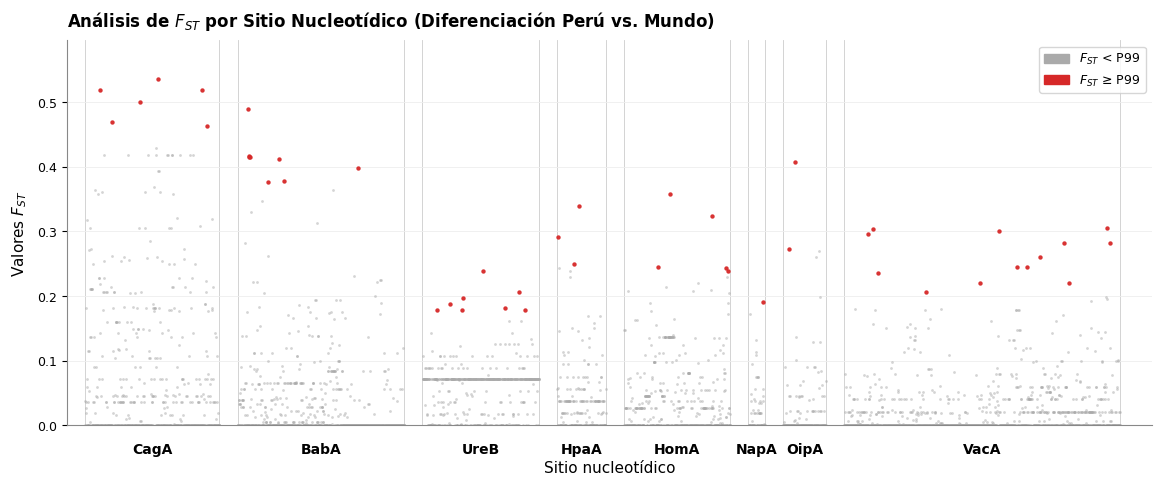

Guardado: manhattan_fst_real.png


In [17]:
# ============================================================
# MANHATTAN PLOT - Fst por Sitio (Perú vs. Mundo, H. pylori)
# Fondo blanco, estilo paper — listo para Google Colab
# ============================================================

# ── 0. Descargar datos desde Google Drive ───────────────────
# !pip install gdown -q
import gdown
file_id = "1JOXcCMqMo9wuKAp6jIE6Iym0A9XJ_TOX"
gdown.download(f"https://drive.google.com/uc?id={file_id}",
               "manhattan_plot_fase1.csv", quiet=False)

# ── 1. Imports ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── 2. Cargar datos ──────────────────────────────────────────
df = pd.read_csv("manhattan_plot_fase1.csv")
print(f"Filas cargadas: {len(df)}")

# ── 3. Parámetros reales (de tu output de R) ─────────────────
# Gen → (Fst_medio, P99)
info_genes = {
    "OG0001326_CagA": (0.12059, 0.43030),
    "OG0000047_BabA": (0.05554, 0.37169),
    "OG0000053_UreB": (0.05464, 0.17857),
    "OG0000677_HpaA": (0.04784, 0.24910),
    "OG0001247_HomA": (0.04578, 0.23266),
    "OG0000366_NapA": (0.03568, 0.17729),
    "OG0000029_OipA": (0.03427, 0.27024),
    "OG0000123_VacA": (0.01593, 0.20482),
}

# Orden de más a menos diferenciado
ORDEN = [
    "OG0001326_CagA", "OG0000047_BabA", "OG0000053_UreB",
    "OG0000677_HpaA", "OG0001247_HomA", "OG0000366_NapA",
    "OG0000029_OipA", "OG0000123_VacA",
]

# ── 4. Construir coordenadas X continuas ─────────────────────
GAP = 80   # separación visual entre genes
df["x_global"] = np.nan
gene_spans = {}  # gen → (x_start, x_end, midpoint)
cursor = 0

for gen in ORDEN:
    sub = df[df["Gen"] == gen].copy()
    if sub.empty:
        continue
    x0 = cursor
    x1 = cursor + sub["Posicion"].max()
    df.loc[df["Gen"] == gen, "x_global"] = sub["Posicion"] + cursor
    gene_spans[gen] = (x0, x1, (x0 + x1) / 2)
    cursor = x1 + GAP

# ── 5. Figura ────────────────────────────────────────────────
GREY = "#aaaaaa"
RED  = "#d62828"

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for gen in ORDEN:
    if gen not in gene_spans:
        continue

    sub = df[df["Gen"] == gen]
    x0, x1, mid = gene_spans[gen]
    fst_m, p99  = info_genes[gen]

    # Puntos grises — bajo P99
    mask_grey = sub["Fst"] < p99
    ax.scatter(sub.loc[mask_grey, "x_global"],
               sub.loc[mask_grey, "Fst"],
               color=GREY, s=4, alpha=0.5, linewidths=0, zorder=2)

    # Puntos rojos — sobre P99 (significativos)
    mask_sig = ~mask_grey
    ax.scatter(sub.loc[mask_sig, "x_global"],
               sub.loc[mask_sig, "Fst"],
               color=RED, s=10, alpha=0.95, linewidths=0, zorder=3)

    # Separadores verticales suaves entre genes
    ax.axvline(x0, color="#cccccc", lw=0.6, zorder=1)
    ax.axvline(x1, color="#cccccc", lw=0.6, zorder=1)

    # CORRECCIÓN AQUÍ: Modificado xytext de -38 a -12 para acercar los nombres
    short = gen.split("_")[1]   # CagA, BabA, etc.
    ax.annotate(short,
                xy=(mid, 0),
                xycoords=("data", "axes fraction"),
                xytext=(0, -12),          # Acercado al eje X
                textcoords="offset points",
                ha="center", va="top",
                fontsize=10, fontweight="bold", # Un poco más grueso para que resalte
                color="black", rotation=0,      # Horizontal se lee mejor, cámbialo a 30 si prefieres
                annotation_clip=False)

# ── 6. Estética ──────────────────────────────────────────────
ax.set_xlim(-80, cursor + 60)
ax.set_ylim(0, df["Fst"].max() + 0.06)

ax.set_ylabel("Valores $F_{ST}$", fontsize=11, labelpad=6)

# CORRECCIÓN AQUÍ: Reducido el labelpad de 55 a 25 para acomodar el título del eje
ax.set_xlabel("Sitio nucleotídico", fontsize=11, labelpad=25)

ax.set_title(
    "Análisis de $F_{ST}$ por Sitio Nucleotídico (Diferenciación Perú vs. Mundo)",
    fontsize=12, pad=10, loc="left"
)

ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", bottom=False, labelbottom=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_color("#888888")
ax.spines["left"].set_color("#888888")
ax.yaxis.grid(True, color="#eeeeee", lw=0.6)

# Leyenda
legend_elements = [
    mpatches.Patch(color=GREY, label="$F_{ST}$ < P99"),
    mpatches.Patch(color=RED,  label="$F_{ST}$ ≥ P99"),
]
ax.legend(handles=legend_elements, loc="upper right",
          frameon=True, fontsize=9, edgecolor="#cccccc")

# ── 7. Guardar ───────────────────────────────────────────────
plt.savefig("manhattan_fst_real.png", dpi=200,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Guardado: manhattan_fst_real.png")